# Regression using autodiff & gradient descent

In [1]:
import matplotlib.pyplot as plt
from trexdiff import Node, finite_diff
import numpy as np

In [2]:
np.random.seed(11)

In [3]:
A, B = np.random.uniform(0, 5, size=(2,))
N = 50
noise_std = 1.5e-1

xs = np.random.uniform(0, 1, size=(N,))
ys = A * xs + B + np.random.normal(scale=noise_std, size=(N,))

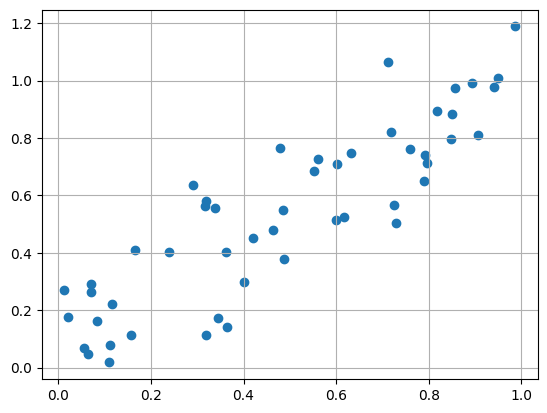

In [4]:
plt.scatter(xs, ys)
plt.grid()

In [5]:
N_iter = 500

# input
x = Node(0.0)
a = Node(0.0)
b = Node(0.0)

y = Node(0.0)
y_p = a * x + b
l = (y - y_p) * (y - y_p)


In [6]:
mu = 2.5e-1
losses = []

for iter in range(N_iter):
    l.zerograd()

    for i in range(N):
        x.val = xs[i]
        y.val = ys[i]

        l.forward()
        l.backward()

    a.val -= mu * a.grad / N
    b.val -= mu * b.grad / N

    losses.append(l.val)

    if iter % 100 == 0:
        print(f"iter {iter}, sample {i}, loss: {l.val:.6f}, "
                f"grad: da={a.grad:.6f}, db={b.grad:.6f}")
   

iter 0, sample 49, loss: 0.162907, grad: da=-34.024063, db=-53.698032
iter 100, sample 49, loss: 0.000575, grad: da=-0.132568, db=0.069299
iter 200, sample 49, loss: 0.000441, grad: da=-0.003758, db=0.001965
iter 300, sample 49, loss: 0.000438, grad: da=-0.000107, db=0.000056
iter 400, sample 49, loss: 0.000438, grad: da=-0.000003, db=0.000002


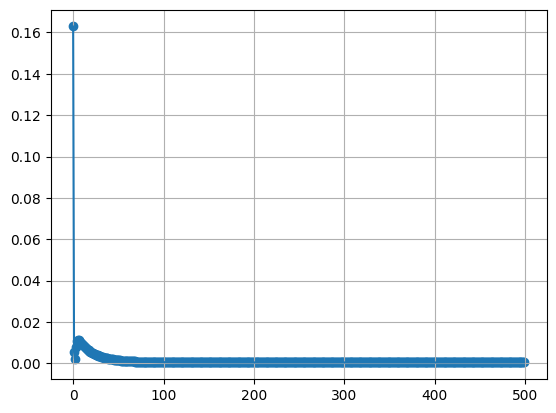

In [7]:
plt.scatter(range(N_iter), losses)
plt.plot(range(N_iter), losses)
plt.grid()

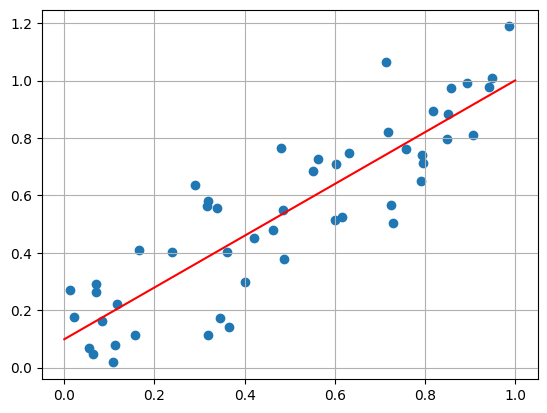

In [8]:
plt.scatter(xs, ys)
plt.plot(
    np.array([0, 1]),
    np.array([b.val, a.val + b.val]),
    c='r'
)
plt.grid()

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr = LinearRegression()
lr.fit(xs.reshape(-1, 1), ys)
print(f"sklearn: a={lr.coef_[0]:.6f}, b={lr.intercept_:.6f}")
print(f"trexdiff: a={a.val:.6f}, b={b.val:.6f}")


sklearn: a=0.901964, b=0.098498
trexdiff: a=0.901964, b=0.098498


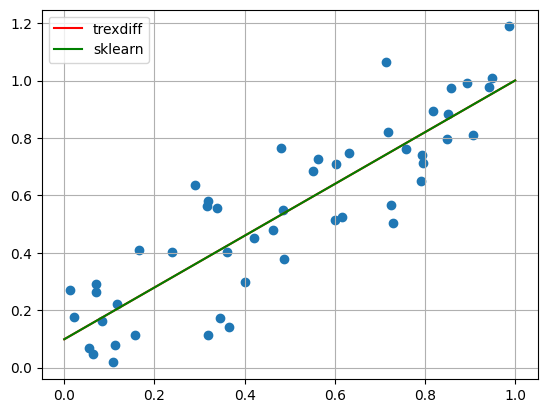

In [11]:
plt.scatter(xs, ys)
plt.plot(
    np.array([0, 1]),
    np.array([b.val, a.val + b.val]),
    c='r',
    label='trexdiff'
)
plt.plot(
    np.array([0, 1]),
    np.array([lr.intercept_, lr.coef_[0] + lr.intercept_]),
    c='g',
    label='sklearn'
)
plt.legend()
plt.grid()